In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
outfolder_="fitsmse_median_increasinginput_lessparsv1"
dataf="subsetdata_median.json"
with open(os.path.join(outfolder_,dataf)) as f:
    d = json.load(f)
    

In [3]:
d

{'WTendo-LS': [0.0, 0.93, 7.37, 31.68, 46.99],
 'WTendo-HS': [0.47, 16.67, 58.14, 91.56, 94.25],
 'WTminigene-LS': [0.1775, 0.6525, 7.175, 54.707499999999996],
 'WTminigene-HS': [2.1550000000000002, 7.285, 43.2875, 93.32249999999999],
 'U1cons_a-LS': [2.48, 2.56, 26.88, 89.09],
 'U1cons_a-HS': [7.32, 15.37, 48.205, 95.18],
 'U1cons_b-LS': [5.449999999999999, 12.485, 50.865, 92.865],
 'U1cons_b-HS': [8.83, 36.83, 74.04, 97.14],
 'BP_stg1-LS': [0.65, 2.7800000000000002, 27.95, 78.735],
 'BP_stg1-HS': [17.69, 43.97, 74.72, 96.41],
 'BP_weak3-LS': [0.0, 0.025, 0.315, 0.95],
 'BP_weak3-HS': [0.28, 1.88, 14.75, 47.8]}

In [4]:
allgroups_subset=[]
mediandata_subset=[]
for k,v in d.items():
    v=np.asarray(v)
    if not "U1cons_a" in k:
        allgroups_subset.append(k)
        if "WTendo" in k:
            v=v[[0,1,2,4]]
        
        mediandata_subset.append(v)


In [5]:
mediandata_subset

[array([ 0.  ,  0.93,  7.37, 46.99]),
 array([ 0.47, 16.67, 58.14, 94.25]),
 array([ 0.1775,  0.6525,  7.175 , 54.7075]),
 array([ 2.155 ,  7.285 , 43.2875, 93.3225]),
 array([ 5.45 , 12.485, 50.865, 92.865]),
 array([ 8.83, 36.83, 74.04, 97.14]),
 array([ 0.65 ,  2.78 , 27.95 , 78.735]),
 array([17.69, 43.97, 74.72, 96.41]),
 array([0.   , 0.025, 0.315, 0.95 ]),
 array([ 0.28,  1.88, 14.75, 47.8 ])]

In [7]:
#inputnames_mini="GFP,CTR,LOW,HIGH".split(",") #minigene
#inputnames_endo="GFP,CTR,LOW,MID,HIGH".split(",") #endogenous

In [6]:
mediandata_subset=np.array(mediandata_subset)
mediandata_subset

array([[0.00000e+00, 9.30000e-01, 7.37000e+00, 4.69900e+01],
       [4.70000e-01, 1.66700e+01, 5.81400e+01, 9.42500e+01],
       [1.77500e-01, 6.52500e-01, 7.17500e+00, 5.47075e+01],
       [2.15500e+00, 7.28500e+00, 4.32875e+01, 9.33225e+01],
       [5.45000e+00, 1.24850e+01, 5.08650e+01, 9.28650e+01],
       [8.83000e+00, 3.68300e+01, 7.40400e+01, 9.71400e+01],
       [6.50000e-01, 2.78000e+00, 2.79500e+01, 7.87350e+01],
       [1.76900e+01, 4.39700e+01, 7.47200e+01, 9.64100e+01],
       [0.00000e+00, 2.50000e-02, 3.15000e-01, 9.50000e-01],
       [2.80000e-01, 1.88000e+00, 1.47500e+01, 4.78000e+01]])

In [15]:
ar=np.arange(10)
np.random.shuffle(ar)
ar

array([0, 8, 2, 6, 9, 7, 4, 3, 1, 5])

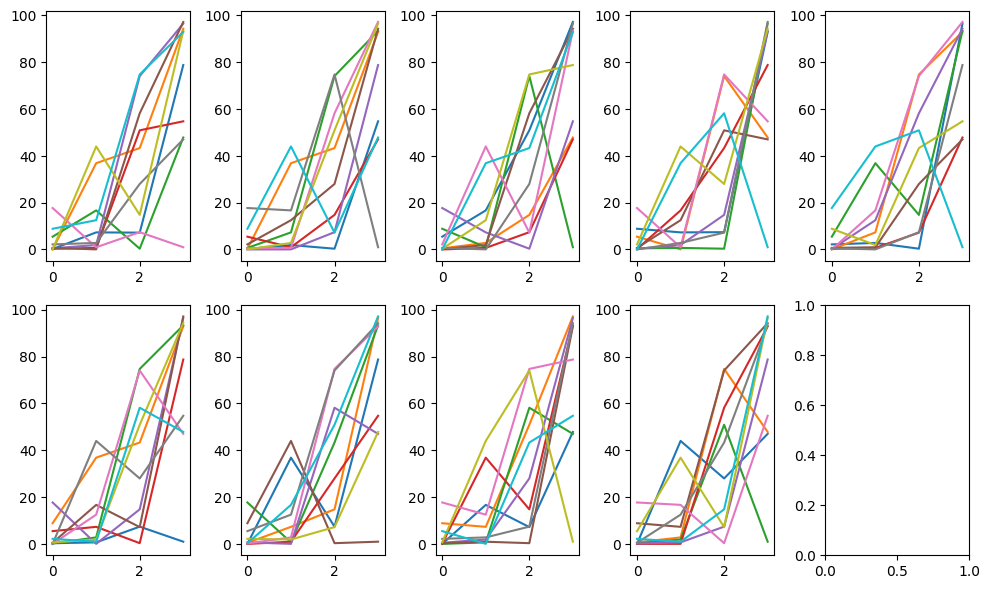

In [17]:
fig,axes=plt.subplots(2,5,figsize=(10,6))
for i in range(9):
    ax=axes[i//5][i%5]
    np.random.seed(i)
    permuted=np.zeros_like(mediandata_subset)
    for k in range(4):
        ar=mediandata_subset[:,k].copy()
        np.random.shuffle(ar)
        permuted[:,k]=ar
    datar=permuted
    for k in range(len(datar)):
        ax.plot(range(4),datar[k])
    np.savetxt("mediandata_permut_%d.txt"%i,permuted)
plt.tight_layout()
plt.show()
#for i in range(9):
    
    #

In [ ]:
np